In [1]:
import mudpy
import os

In [50]:

import random
def get_rupts(dir):
    try:
        files=os.listdir(dir)
        list_rupt=[]
        num_entries=300
        for file in files:
            extension=file.split(".")[-1]
            if extension=="rupt" and len(list_rupt) < num_entries:
                mw=round(float(get_mw(file,dir)),2)
                if mw >= 8.95 and mw <= 9.1:
                    list_rupt.append(file)
                else:
                    continue
            else:
                continue
        
        print(len(list_rupt))
        if len(list_rupt) < num_entries:
            raise ValueError("List too smol")
        elif len(list_rupt) == num_entries:

            return random.sample(list_rupt,num_entries)
    except Exception as e:
        print(f"An error occurred: {e}")
def get_mw(filename,dir):
    search_text="Actual magnitude: Mw"
    filename=f"{dir}/{filename.split('.')[0]}.{filename.split('.')[1]}.log"
    #print(filename)
    with open(filename,"r") as file:
        for line in file:
            if search_text in line:
            
                return(line.split(" ")[-1])
        return(None)
def process_rupt(ls,dir):
    import pandas as pd
    files=ls
    
    ls_file=[]
    ls_mw=[]
    for file in files:
        log_file=f"{file.split('.')[0]}.{file.split('.')[1]}.dtopo"
        mw=float(get_mw(log_file,dir))
        ls_file.append(log_file)
        ls_mw.append(mw)
    mw_dict={"File":ls_file,"Mw":ls_mw}
    df_mw=pd.DataFrame(mw_dict)
    return(df_mw)
def plot_mw_distribution(mw_ls):
    import matplotlib.pyplot as plt
    import numpy as np
    mw_ls=np.array(mw_ls)
    n_bins=10
    plt.hist(mw_ls,n_bins)

300


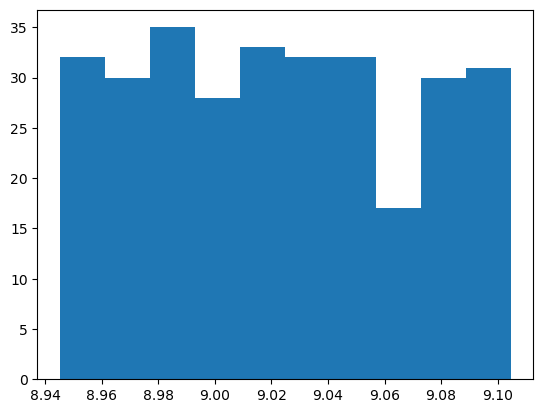

In [51]:
target_directory_gamma="/hdd/ssantellanes/4zenodo/gamma"
rupt_files_gamma=get_rupts(target_directory_gamma)
mw_ls_gamma=process_rupt(rupt_files_gamma,target_directory_gamma)
mw_ls_gamma_mw=mw_ls_gamma["Mw"].to_numpy()
plot_mw_distribution(mw_ls_gamma_mw)

300


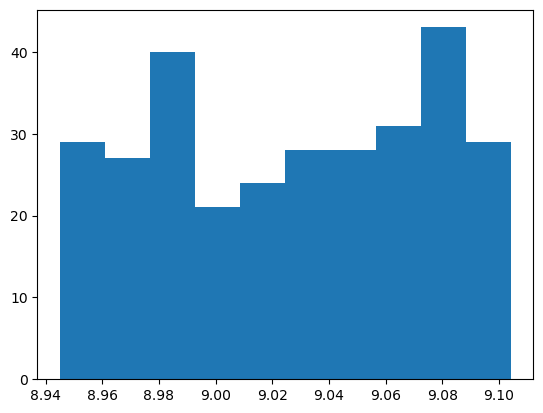

In [52]:

target_directory_gauss="/hdd/ssantellanes/4zenodo/gauss"
rupt_files_gauss=get_rupts(target_directory_gauss)
mw_ls_gauss=process_rupt(rupt_files_gauss,target_directory_gauss)
mw_ls_gauss_mw=mw_ls_gauss["Mw"].to_numpy()
plot_mw_distribution(mw_ls_gauss_mw)

target_directory_Li="/hdd/ssantellanes/4zenodo/"
rupt_files_Li=get_rupts(target_directory_Li)
mw_ls_Li=process_rupt(rupt_files_Li,target_directory_Li)
plot_mw_distribution(mw_ls_Li)

300


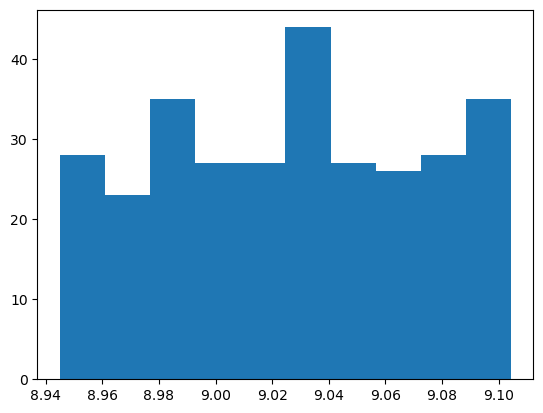

In [53]:
target_directory_1cm="/hdd/ssantellanes/4zenodo/1cm"
rupt_files_1cm=get_rupts(target_directory_1cm)
mw_ls_1cm=process_rupt(rupt_files_1cm,target_directory_1cm)
mw_ls_1cm_mw=mw_ls_1cm["Mw"].to_numpy()
plot_mw_distribution(mw_ls_1cm_mw)

In [35]:
rupt_files=rupt_files_gamma+rupt_files_gauss+rupt_files_1cm

In [7]:
file=rupt_files[78]
print(file.split('.')[0].split('_')[-1])

NameError: name 'rupt_files' is not defined

In [6]:
from mudpy.forward import move_seafloor_okada
import os
def make_dtopos(files,output_dir):
    for file in files:
        directory=file.split('.')[0].split('_')[-1]
        #target_dir=f"/hdd/ssantellanes/4zenodo/{directory}"
        target_dir="/home/ssantellanes/Tsunami/Cascadia/"
        input_file=f"{target_dir}/{file}"
        output_file=f"{output_dir}{file.split('.')[0]}.{file.split('.')[1]}.dtopo"
        move_seafloor_okada(input_file,output_file)

In [14]:
files=["/home/ssantellanes/Tsunami/Cascadia/cascadia1700_1cm.006154.rupt", "/home/ssantellanes/Tsunami/Cascadia/cascadia1700_gamma.006285.rupt", "/home/ssantellanes/Tsunami/Cascadia/cascadia1700_gauss.006345.rupt", "/home/ssantellanes/Tsunami/Cascadia/cascadia1700_li.006367.rupt"]
out_dir="/home/ssantellanes/new_fig2/"
move_seafloor_okada(files[3],"cascadia1700_li.006367.dtopo")

In [41]:
len(rupt_files)

900

In [94]:
out_dir="/home/ssantellanes/NASA_DTOPOS/NASA_1CM_DTOPOS/"
make_dtopos(rupt_files_1cm,out_dir)

In [95]:
import os
# List the contents of the current directory
dir_contents = os.listdir("/home/ssantellanes/NASA_DTOPOS/NASA_1CM_DTOPOS")

# Create and save the contents to a txt file
file_path = "/home/ssantellanes/NASA_1CM_dtopos.txt"
with open(file_path, 'w') as file:
    for item in dir_contents:
        file.write(f"{item}\n")

file_path

'/home/ssantellanes/NASA_1CM_dtopos.txt'

In [96]:
mw_ls_1cm.to_csv("/home/ssantellanes/NASA_1CM_dtopos_df.txt",index=False)

In [97]:
import pandas as pd
df1=pd.read_csv("/home/ssantellanes/NASA_1CM_dtopos.txt",names=["File"])
df1=df1.sort_values("File")
df1

,File
118,cascadia1700_1cm.000000.dtopo
188,cascadia1700_1cm.000002.dtopo
247,cascadia1700_1cm.000003.dtopo
55,cascadia1700_1cm.000006.dtopo
29,cascadia1700_1cm.000007.dtopo
...,...
175,cascadia1700_1cm.000968.dtopo
45,cascadia1700_1cm.000969.dtopo
16,cascadia1700_1cm.000983.dtopo
144,cascadia1700_1cm.000990.dtopo


In [98]:
df2=pd.read_csv("/home/ssantellanes/NASA_1CM_dtopos_df.txt")
df2=df2.sort_values("File")
df2

,File,Mw
86,cascadia1700_1cm.000000.dtopo,9.0309
69,cascadia1700_1cm.000002.dtopo,8.9950
51,cascadia1700_1cm.000003.dtopo,8.9575
17,cascadia1700_1cm.000006.dtopo,8.9560
110,cascadia1700_1cm.000007.dtopo,9.0266
...,...,...
189,cascadia1700_1cm.000968.dtopo,8.9892
266,cascadia1700_1cm.000969.dtopo,9.0468
202,cascadia1700_1cm.000983.dtopo,9.0589
233,cascadia1700_1cm.000990.dtopo,9.0952


In [99]:
file_list_1=df1["File"].to_list()
file_list_2=df2["File"].to_list()
for string in file_list_1:
    if string in file_list_2:
        continue
    else:
        print(f"{string} not in file_list_2")

In [100]:
for string in file_list_2:
    if string in file_list_1:
        continue
    else:
        print(f"{string} not in file_list_1")

In [101]:
dir_contents

['cascadia1700_1cm.000282.dtopo',
 'cascadia1700_1cm.000125.dtopo',
 'cascadia1700_1cm.000493.dtopo',
 'cascadia1700_1cm.000659.dtopo',
 'cascadia1700_1cm.000741.dtopo',
 'cascadia1700_1cm.000105.dtopo',
 'cascadia1700_1cm.000622.dtopo',
 'cascadia1700_1cm.000630.dtopo',
 'cascadia1700_1cm.000464.dtopo',
 'cascadia1700_1cm.000331.dtopo',
 'cascadia1700_1cm.000521.dtopo',
 'cascadia1700_1cm.000171.dtopo',
 'cascadia1700_1cm.000628.dtopo',
 'cascadia1700_1cm.000021.dtopo',
 'cascadia1700_1cm.000485.dtopo',
 'cascadia1700_1cm.000256.dtopo',
 'cascadia1700_1cm.000983.dtopo',
 'cascadia1700_1cm.000698.dtopo',
 'cascadia1700_1cm.000313.dtopo',
 'cascadia1700_1cm.000042.dtopo',
 'cascadia1700_1cm.000696.dtopo',
 'cascadia1700_1cm.000704.dtopo',
 'cascadia1700_1cm.000524.dtopo',
 'cascadia1700_1cm.000302.dtopo',
 'cascadia1700_1cm.000383.dtopo',
 'cascadia1700_1cm.000734.dtopo',
 'cascadia1700_1cm.000573.dtopo',
 'cascadia1700_1cm.000967.dtopo',
 'cascadia1700_1cm.000413.dtopo',
 'cascadia1700

In [102]:
for string in dir_contents:
    if string in file_list_2:
        continue
    else:
        print(f"{string} not in /home/ssantellanes/NASA_DTOPOS/NASA_GAUSS_DTOPOS")

In [103]:
import numpy as np
def switch_dtopo_lon(dir):
    files=os.listdir(dir)
    for file in files:
        if file.split(".")[-1] == "dtopo":
            
            dtopo=np.genfromtxt(f"{dir}{file}")
            #print(f"{dir}{file}")
            dtopo[:,1]=dtopo[:,1]-360
            out_dtopo=f"{dir}{file}"
            np.savetxt(out_dtopo,dtopo,fmt=["%.2f","%.4f","%.4f","%.2f"])

In [106]:
li_dir="/home/ssantellanes/NASA_DTOPOS/NASA_GAMMA_DTOPOS/"
switch_dtopo_lon(li_dir)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
output_file="/hdd/ssantellanes/powell_sans_mw/USGS-A-Sd-S-Sym-M-AS-result.dtopo"
dtopo=np.genfromtxt(output_file)
mask=~np.any(dtopo==0,axis=1)
dtopo=dtopo[mask]
plt.scatter(dtopo[:,1],dtopo[:,2],c=dtopo[:,3],vmin=-10,vmax=10,s=10,marker="s",cmap="seismic")
cbar=plt.colorbar()
cbar.set_label("Sea floor displacement (m)")

: 

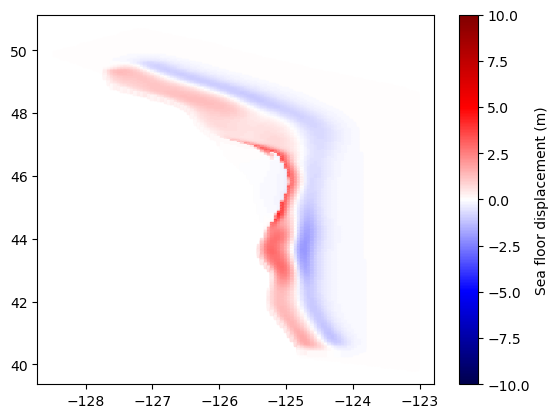

In [4]:
import matplotlib.pyplot as plt
import numpy as np
output_file="/home/ssantellanes/powell/USGS-A-Sd-S-Sym-M-A2-result.dtopo"
dtopo=np.genfromtxt(output_file)
#mask=~np.any(dtopo==0,axis=1)
#dtopo=dtopo[mask]
plt.scatter(dtopo[:,1],dtopo[:,2],c=dtopo[:,3],vmin=-10,vmax=10,s=10,marker="s",cmap="seismic")
cbar=plt.colorbar()
cbar.set_label("Sea floor displacement (m)")